Analyze the scans preprocessing - how many scans were disqualified, why, manual classification and source 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
# 1 = Good, = color code = green
# 2 = pixeled (cubes in the scan) = color code = orange
# 3 = striped (slices too big) = color code = orange 
# 4 = black jpg, 
# 5 = not usable scan (partial brain) = color code = red

# 1. Define descriptive names and the specific color mapping
# We use strings because after renaming columns, the labels will be text
label_names = {
    1.0: '1: Good',
    2.0: '2: Pixeled',
    3.0: '3: Striped',
    4.0: '4: Black JPG',
    5.0: '5: Not Usable',
    'Missing': 'Missing'
}

# Map the descriptive names to your colors
# Note: 2 and 3 both map to orange as requested
color_map = {
    '1: Good': 'green',
    '2: Pixeled': 'orange',
    '3: Striped': 'orange',
    '4: Black JPG': 'black',
    '5: Not Usable': 'red',
    'Missing': 'gray' # Adding a neutral color for NaNs
}

In [2]:
final_labeled_scans = pd.read_csv("/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/manual_labels_resolved_duplicates.csv")

combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')

# remove duplicates based on subject_id and session_id
combined_df_scans = combined_df.drop_duplicates(subset=['subject_id', 'session_id'])

combined_df_scans['source'] = combined_df_scans['source'].astype(str)

/tmp/ipykernel_215123/1843300100.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_scans['source'] = combined_df_scans['source'].astype(str)


### comparison between the manually-labeled scans and combined_df

In [3]:
# preperations for comparison 

# remove 'file_path' column from labeled_scans 
labeled_scans_for_compartison = final_labeled_scans[['subject_id', 'session_id', 'classification_label']]

# remove "sub-" prefix from subject_id and "ses-" prefix from session_id
labeled_scans_for_compartison['subject_id'] = labeled_scans_for_compartison['subject_id'].str.replace('sub-', '', regex=False)
labeled_scans_for_compartison['session_id'] = labeled_scans_for_compartison['session_id'].str.replace('ses-', '', regex=False)

# add comparison key (subject_id + session_id combination)
labeled_scans_for_compartison['key'] = labeled_scans_for_compartison['subject_id'].astype(str) + '_' + labeled_scans_for_compartison['session_id'].astype(str)
combined_df_scans['key'] = combined_df_scans['subject_id'].astype(str) + '_' + combined_df_scans['session_id'].astype(str)


/tmp/ipykernel_215123/5129102.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labeled_scans_for_compartison['subject_id'] = labeled_scans_for_compartison['subject_id'].str.replace('sub-', '', regex=False)
/tmp/ipykernel_215123/5129102.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labeled_scans_for_compartison['session_id'] = labeled_scans_for_compartison['session_id'].str.replace('ses-', '', regex=False)
/tmp/ipykernel_215123/5129102.py:11: SettingWithCopyWarning: 
A value is trying to be set on a

In [4]:
# in manual label, not in combined_df
missing_scans = labeled_scans_for_compartison[~labeled_scans_for_compartison['key'].isin(combined_df['key'])]
missing_scans = missing_scans.drop_duplicates(subset=['key'])
print(f"Number of scans that were manually labeled but not in combined_df: {len(missing_scans)}")

Number of scans that were manually labeled but not in combined_df: 846


In [5]:
# in combined_df, not labeled and not snbb
unlabeled_scans = combined_df[~combined_df['key'].isin(labeled_scans_for_compartison['key'])]
unlabeled_scans = unlabeled_scans[unlabeled_scans['source'] != 'snbb']
unlabeled_scans = unlabeled_scans.drop_duplicates(subset=['key'])
print(f"Number of scans in combined df that are not source==snbb and were NOT manually labeled: {len(unlabeled_scans)}")

Number of scans in combined df that are not source==snbb and were NOT manually labeled: 687


In [6]:
# separate snbb from the rest
snbb_scans = combined_df_scans[combined_df_scans['source'] == 'snbb']
old_scans = combined_df_scans[combined_df_scans['source'] != 'snbb']

In [7]:
print(f"amount of scans from snbb source: {snbb_scans.shape[0]}")


amount of scans from snbb source: 3817


In [11]:
print(f"diqualified old scans because sesison_id is nan: {old_scans[old_scans['session_id']=='nan'].shape[0]}")
print(f"amount of good old scans: {old_scans[old_scans['session_id']!='nan'].shape[0]}")
print(f"total old scans: {old_scans.shape[0]}")

diqualified old scans because sesison_id is nan: 687
amount of good old scans: 264
total old scans: 951


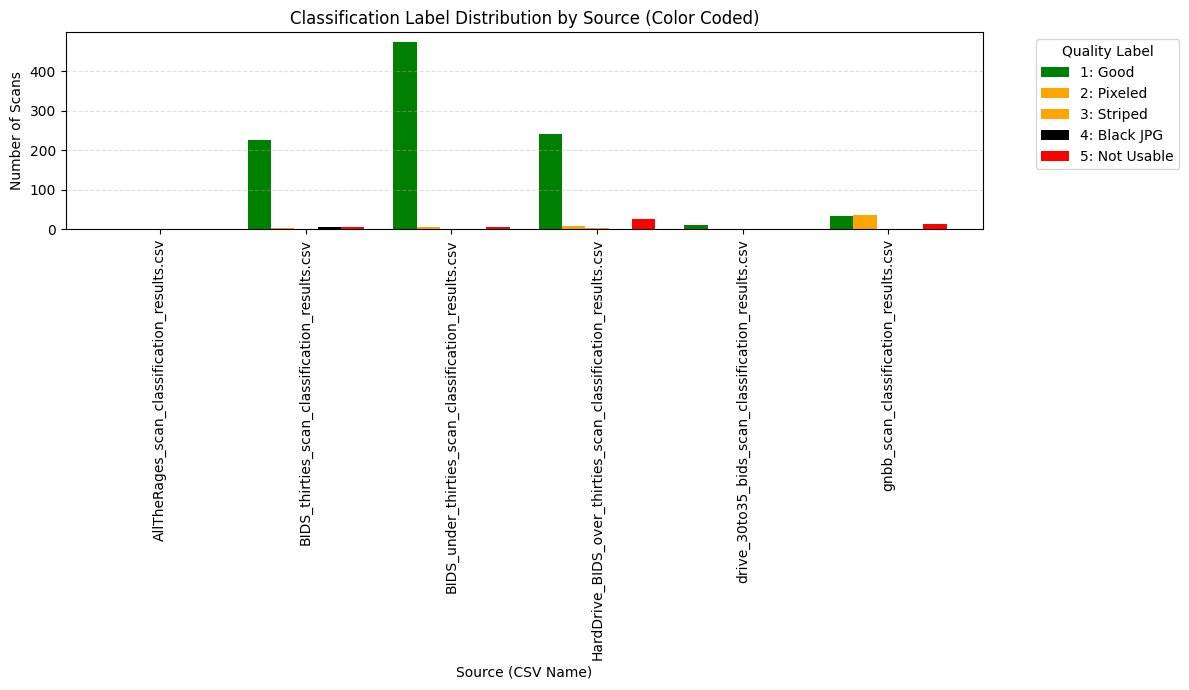

In [26]:
# 2. Create the counts including NaNs
counts_df = (
    final_labeled_scans.groupby('csv_name')['classification_label']
    .value_counts(dropna=False)
    .unstack(fill_value=0)
)

# 3. Rename columns to descriptive strings
# This handles both the numeric labels and the various forms of NaN
counts_df = counts_df.rename(columns={
    pd.NA: 'Missing', 
    float('nan'): 'Missing',
    None: 'Missing'
})
counts_df = counts_df.rename(columns=label_names)

# 4. Ensure the columns are plotted in a specific order if they exist
# This prevents the colors from shifting if a source is missing a specific label
plot_order = [label for label in label_names.values() if label in counts_df.columns]
final_colors = [color_map[label] for label in plot_order]

# 5. Plot
ax = counts_df[plot_order].plot(
    kind='bar', 
    figsize=(12, 7), 
    width=0.8, 
    color=final_colors
)

plt.title('Classification Label Distribution by Source (Color Coded)')
plt.xlabel('Source (CSV Name)')
plt.ylabel('Number of Scans')
plt.legend(title='Quality Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

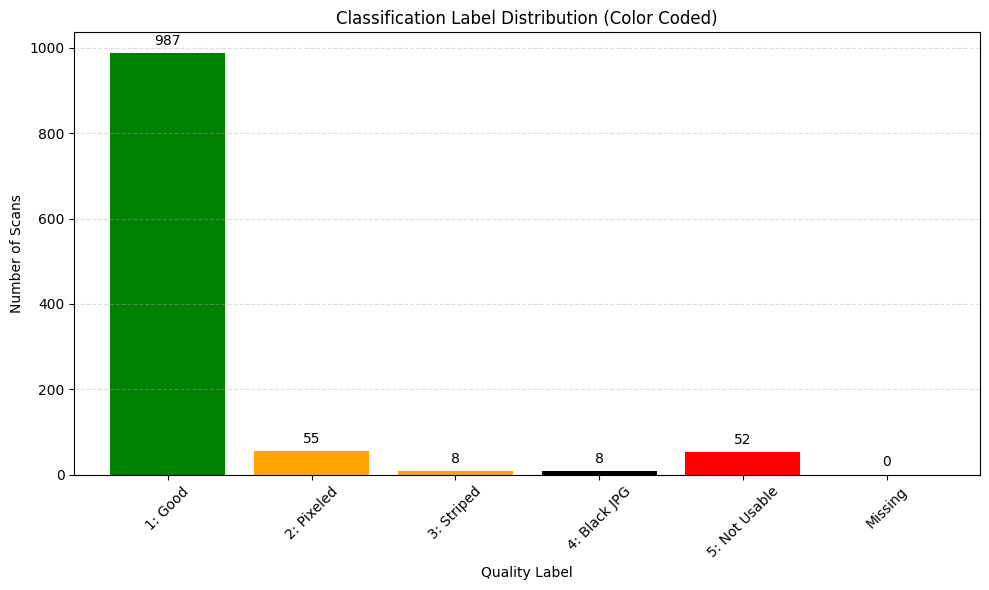

In [29]:
# 2. Calculate counts and handle NaNs
counts_series = final_labeled_scans['classification_label'].value_counts(dropna=False)

# Rename the index using the descriptive labels
# We handle the various NaN types first, then map the numbers to names
counts_series.index = [label_names.get(i, 'Missing') if pd.notna(i) else 'Missing' for i in counts_series.index]

# 3. Reorder to ensure they appear in 1, 2, 3... order
# This ensures the chart is logical even if some categories are small
order = ['1: Good', '2: Pixeled', '3: Striped', '4: Black JPG', '5: Not Usable', 'Missing']
counts_series = counts_series.reindex(order).fillna(0)

# 4. Map the colors to the specific labels present in our series
colors = [color_map[label] for label in counts_series.index]

# 5. Plot
plt.figure(figsize=(10, 6))
ax = counts_series.plot(kind='bar', width=0.8, color=colors)

plt.title('Classification Label Distribution (Color Coded)')
plt.xlabel('Quality Label')
plt.ylabel('Number of Scans')
plt.xticks(rotation=45) # Reduced rotation for better readability of descriptions
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Optional: Add text labels on top of bars for 3M row datasets
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

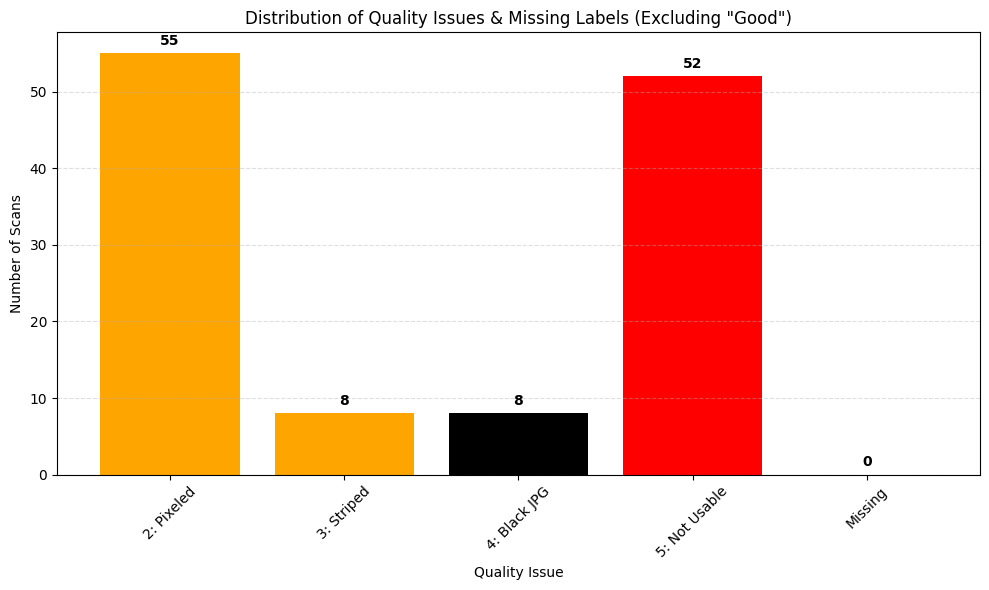

In [30]:
# 2. Filter out the "Good" labels (1) and calculate counts
# We focus only on the issues and missing values
filtered_scans = final_labeled_scans[final_labeled_scans['classification_label'] != 1]
counts_series = filtered_scans['classification_label'].value_counts(dropna=False)

# 3. Rename the index to descriptive names
counts_series.index = [label_names.get(i, 'Missing') if pd.notna(i) else 'Missing' for i in counts_series.index]

# 4. Reindex to ensure a logical order (2, 3, 4, 5, Missing)
order = ['2: Pixeled', '3: Striped', '4: Black JPG', '5: Not Usable', 'Missing']
counts_series = counts_series.reindex(order).fillna(0)

# 5. Map the colors to the labels present in the filtered series
colors = [color_map[label] for label in counts_series.index]

# 6. Plot
plt.figure(figsize=(10, 6))
ax = counts_series.plot(kind='bar', width=0.8, color=colors)

plt.title('Distribution of Quality Issues & Missing Labels (Excluding "Good")')
plt.xlabel('Quality Issue')
plt.ylabel('Number of Scans')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Add text labels on top of bars so you can see exact numbers for the 3M row dataset
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()